In [2]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:22px;}
</style>
"""))

In [1]:
# GPU 활성화 끄기
import os
os.environ['CUDA_VISIBLE_DEVICES'] = "-1"
# GPU 사용 여부 확인
import tensorflow as tf
print(tf.__version__)
tf.config.list_physical_devices('GPU')

2.10.0


[]

# 1. 기존의 프로그램 방식

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 섭씨온도(input data)를 받아 화씨 온도로 출력
def celsius_to_faherenheit(c):
    return 1.8*c + 32

In [4]:
input_data = int(input('섭씨온도는?'))
print('화씨온도는 ', celsius_to_faherenheit(input_data))

섭씨온도는?0
화씨온도는  32.0


# 2. 머신러닝/딥러닝 프로그램 방식
- 1. 데이터 확보 및 생성
- 2. 데이터 전처리 : scale조정, 라벨링처리, 훈련데이터셋(학습데이터셋), 검증데이터셋, 시험데이터셋으로 나누기
- 3. 모델구성
- 4. 모델 학습과정 설정
- 5. 모델 학습시키기(학습데이터셋과 검증데이터셋으로)
- 6. 모델 평가(시험데이터셋으로)
- 7. 모델 사용(입력값이 주어지면 예측값을 받기)

## 2.1 노이즈가 없는 데이터로 실습

In [5]:
# 1. 데이터 생성
data_C = np.arange(100)
data_C # 입력변수==독립변수

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [6]:
data_F = celsius_to_faherenheit(data_C)
data_F # 타겟변수==종속변수

array([ 32. ,  33.8,  35.6,  37.4,  39.2,  41. ,  42.8,  44.6,  46.4,
        48.2,  50. ,  51.8,  53.6,  55.4,  57.2,  59. ,  60.8,  62.6,
        64.4,  66.2,  68. ,  69.8,  71.6,  73.4,  75.2,  77. ,  78.8,
        80.6,  82.4,  84.2,  86. ,  87.8,  89.6,  91.4,  93.2,  95. ,
        96.8,  98.6, 100.4, 102.2, 104. , 105.8, 107.6, 109.4, 111.2,
       113. , 114.8, 116.6, 118.4, 120.2, 122. , 123.8, 125.6, 127.4,
       129.2, 131. , 132.8, 134.6, 136.4, 138.2, 140. , 141.8, 143.6,
       145.4, 147.2, 149. , 150.8, 152.6, 154.4, 156.2, 158. , 159.8,
       161.6, 163.4, 165.2, 167. , 168.8, 170.6, 172.4, 174.2, 176. ,
       177.8, 179.6, 181.4, 183.2, 185. , 186.8, 188.6, 190.4, 192.2,
       194. , 195.8, 197.6, 199.4, 201.2, 203. , 204.8, 206.6, 208.4,
       210.2])

In [8]:
# 2. 데이터 전처리 : 컴퓨터에게 학습시키기 위해, Normalize함(변수들의 편차를 비슷하게)
scaled_data_C = data_C/100.0
scaled_data_F = data_F/100.0
print('독립변수는 ', scaled_data_C)
print('종속변수는 ', scaled_data_F)

독립변수는  [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99]
종속변수는  [0.32  0.338 0.356 0.374 0.392 0.41  0.428 0.446 0.464 0.482 0.5   0.518
 0.536 0.554 0.572 0.59  0.608 0.626 0.644 0.662 0.68  0.698 0.716 0.734
 0.752 0.77  0.788 0.806 0.824 0.842 0.86  0.878 0.896 0.914 0.932 0.95
 0.968 0.986 1.004 1.022 1.04  1.058 1.076 1.094 1.112 1.13  1.148 1.166
 1.184 1.202 1.22  1.238 1.256 1.274 1.292 1.31  1.328 1.346 1.364 1.382
 1.4   1.418 1.436 1.454 1.472 1.49  1.508 1.526 1.544 1.562 1.58  1.598
 1.616 1.634 1.652 1.67  1.688 1.706 1.7

In [9]:
# 3. 모델 구성(tensorflow)
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Dense # 입력값과 출력값으로 layer층 지정
model = Sequential()
model.add(Dense(1, # 출력(종속, 타겟)변수의 갯수
               input_shape=(1,) # 입력(독립)변수의 shape
               ))
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________
None


-  회귀분석 오차함수 : 
    MSE(오차제곱평균), RMSE(루트를 취하기 때문에 MSE단점이 어느정도 해소. 덜 민감), MAE(절대값평균)

In [10]:
# 4. 모델 학습 과정 설정
model.compile(loss='mse', optimizer='rmsprop', metrics=['mae'])
               # 손실함수          옵티마저이저      평가지표
# loss(오차, 손실함수)는 모델 학습 중 최적화할 대상
# metrics : 평가지표

In [11]:
# 학습 전 예측
model.predict(np.array([[0],
                        [0.01]]))

1/1 [==============================] - 0s 74ms/step


array([[ 0.        ],
       [-0.01167233]], dtype=float32)

In [12]:
# 학습 전 모델 저장
model.save('model/before_learning.h5') # kernel에 w(기울기), bias에 b이 있음
# from tensorflow.keras.models import save_model
# save_model(model, 'model/before_learning.h5')

In [13]:
# 모델 학습시키기 - 1번만 실행
hist = model.fit(scaled_data_C, scaled_data_F, epochs=1000, verbose=2)
                #  독립변수        타겟변수(종속)   학습횟수    학습시출력여부

Epoch 1/1000
4/4 - 0s - loss: 3.9157 - mae: 1.7842 - 305ms/epoch - 76ms/step
Epoch 2/1000
4/4 - 0s - loss: 3.8729 - mae: 1.7731 - 3ms/epoch - 805us/step
Epoch 3/1000
4/4 - 0s - loss: 3.8412 - mae: 1.7650 - 5ms/epoch - 1ms/step
Epoch 4/1000
4/4 - 0s - loss: 3.8121 - mae: 1.7576 - 4ms/epoch - 882us/step
Epoch 5/1000
4/4 - 0s - loss: 3.7854 - mae: 1.7505 - 2ms/epoch - 613us/step
Epoch 6/1000
4/4 - 0s - loss: 3.7643 - mae: 1.7449 - 5ms/epoch - 1ms/step
Epoch 7/1000
4/4 - 0s - loss: 3.7409 - mae: 1.7389 - 3ms/epoch - 832us/step
Epoch 8/1000
4/4 - 0s - loss: 3.7162 - mae: 1.7323 - 4ms/epoch - 971us/step
Epoch 9/1000
4/4 - 0s - loss: 3.6948 - mae: 1.7268 - 4ms/epoch - 1ms/step
Epoch 10/1000
4/4 - 0s - loss: 3.6728 - mae: 1.7208 - 3ms/epoch - 824us/step
Epoch 11/1000
4/4 - 0s - loss: 3.6492 - mae: 1.7145 - 3ms/epoch - 805us/step
Epoch 12/1000
4/4 - 0s - loss: 3.6275 - mae: 1.7088 - 7ms/epoch - 2ms/step
Epoch 13/1000
4/4 - 0s - loss: 3.6077 - mae: 1.7034 - 3ms/epoch - 873us/step
Epoch 14/1000
4

Epoch 109/1000
4/4 - 0s - loss: 1.8473 - mae: 1.1504 - 2ms/epoch - 555us/step
Epoch 110/1000
4/4 - 0s - loss: 1.8340 - mae: 1.1456 - 5ms/epoch - 1ms/step
Epoch 111/1000
4/4 - 0s - loss: 1.8206 - mae: 1.1407 - 3ms/epoch - 858us/step
Epoch 112/1000
4/4 - 0s - loss: 1.8069 - mae: 1.1358 - 3ms/epoch - 642us/step
Epoch 113/1000
4/4 - 0s - loss: 1.7912 - mae: 1.1298 - 4ms/epoch - 933us/step
Epoch 114/1000
4/4 - 0s - loss: 1.7781 - mae: 1.1252 - 3ms/epoch - 755us/step
Epoch 115/1000
4/4 - 0s - loss: 1.7629 - mae: 1.1197 - 3ms/epoch - 863us/step
Epoch 116/1000
4/4 - 0s - loss: 1.7470 - mae: 1.1138 - 5ms/epoch - 1ms/step
Epoch 117/1000
4/4 - 0s - loss: 1.7333 - mae: 1.1087 - 4ms/epoch - 1ms/step
Epoch 118/1000
4/4 - 0s - loss: 1.7196 - mae: 1.1036 - 3ms/epoch - 821us/step
Epoch 119/1000
4/4 - 0s - loss: 1.7047 - mae: 1.0982 - 5ms/epoch - 1ms/step
Epoch 120/1000
4/4 - 0s - loss: 1.6899 - mae: 1.0927 - 3ms/epoch - 767us/step
Epoch 121/1000
4/4 - 0s - loss: 1.6746 - mae: 1.0869 - 4ms/epoch - 888us

Epoch 215/1000
4/4 - 0s - loss: 0.6722 - mae: 0.6707 - 3ms/epoch - 786us/step
Epoch 216/1000
4/4 - 0s - loss: 0.6643 - mae: 0.6670 - 5ms/epoch - 1ms/step
Epoch 217/1000
4/4 - 0s - loss: 0.6559 - mae: 0.6630 - 4ms/epoch - 1ms/step
Epoch 218/1000
4/4 - 0s - loss: 0.6496 - mae: 0.6599 - 3ms/epoch - 819us/step
Epoch 219/1000
4/4 - 0s - loss: 0.6438 - mae: 0.6571 - 4ms/epoch - 927us/step
Epoch 220/1000
4/4 - 0s - loss: 0.6356 - mae: 0.6531 - 4ms/epoch - 950us/step
Epoch 221/1000
4/4 - 0s - loss: 0.6289 - mae: 0.6499 - 4ms/epoch - 890us/step
Epoch 222/1000
4/4 - 0s - loss: 0.6220 - mae: 0.6465 - 4ms/epoch - 1ms/step
Epoch 223/1000
4/4 - 0s - loss: 0.6146 - mae: 0.6429 - 2ms/epoch - 557us/step
Epoch 224/1000
4/4 - 0s - loss: 0.6076 - mae: 0.6396 - 5ms/epoch - 1ms/step
Epoch 225/1000
4/4 - 0s - loss: 0.6011 - mae: 0.6362 - 5ms/epoch - 1ms/step
Epoch 226/1000
4/4 - 0s - loss: 0.5959 - mae: 0.6336 - 2ms/epoch - 595us/step
Epoch 227/1000
4/4 - 0s - loss: 0.5889 - mae: 0.6302 - 3ms/epoch - 652us/s

Epoch 321/1000
4/4 - 0s - loss: 0.2579 - mae: 0.4394 - 4ms/epoch - 953us/step
Epoch 322/1000
4/4 - 0s - loss: 0.2572 - mae: 0.4387 - 5ms/epoch - 1ms/step
Epoch 323/1000
4/4 - 0s - loss: 0.2560 - mae: 0.4378 - 3ms/epoch - 810us/step
Epoch 324/1000
4/4 - 0s - loss: 0.2548 - mae: 0.4367 - 3ms/epoch - 788us/step
Epoch 325/1000
4/4 - 0s - loss: 0.2534 - mae: 0.4357 - 4ms/epoch - 1ms/step
Epoch 326/1000
4/4 - 0s - loss: 0.2527 - mae: 0.4351 - 4ms/epoch - 1ms/step
Epoch 327/1000
4/4 - 0s - loss: 0.2514 - mae: 0.4339 - 4ms/epoch - 889us/step
Epoch 328/1000
4/4 - 0s - loss: 0.2501 - mae: 0.4329 - 4ms/epoch - 1ms/step
Epoch 329/1000
4/4 - 0s - loss: 0.2490 - mae: 0.4320 - 5ms/epoch - 1ms/step
Epoch 330/1000
4/4 - 0s - loss: 0.2476 - mae: 0.4308 - 4ms/epoch - 927us/step
Epoch 331/1000
4/4 - 0s - loss: 0.2467 - mae: 0.4300 - 3ms/epoch - 756us/step
Epoch 332/1000
4/4 - 0s - loss: 0.2458 - mae: 0.4293 - 3ms/epoch - 808us/step
Epoch 333/1000
4/4 - 0s - loss: 0.2448 - mae: 0.4284 - 3ms/epoch - 784us/s

Epoch 427/1000
4/4 - 0s - loss: 0.1631 - mae: 0.3487 - 2ms/epoch - 567us/step
Epoch 428/1000
4/4 - 0s - loss: 0.1624 - mae: 0.3480 - 3ms/epoch - 639us/step
Epoch 429/1000
4/4 - 0s - loss: 0.1618 - mae: 0.3474 - 4ms/epoch - 1ms/step
Epoch 430/1000
4/4 - 0s - loss: 0.1610 - mae: 0.3465 - 4ms/epoch - 924us/step
Epoch 431/1000
4/4 - 0s - loss: 0.1602 - mae: 0.3457 - 4ms/epoch - 891us/step
Epoch 432/1000
4/4 - 0s - loss: 0.1595 - mae: 0.3448 - 4ms/epoch - 886us/step
Epoch 433/1000
4/4 - 0s - loss: 0.1587 - mae: 0.3441 - 2ms/epoch - 580us/step
Epoch 434/1000
4/4 - 0s - loss: 0.1580 - mae: 0.3433 - 4ms/epoch - 901us/step
Epoch 435/1000
4/4 - 0s - loss: 0.1572 - mae: 0.3424 - 4ms/epoch - 918us/step
Epoch 436/1000
4/4 - 0s - loss: 0.1563 - mae: 0.3415 - 3ms/epoch - 777us/step
Epoch 437/1000
4/4 - 0s - loss: 0.1554 - mae: 0.3405 - 3ms/epoch - 833us/step
Epoch 438/1000
4/4 - 0s - loss: 0.1546 - mae: 0.3396 - 3ms/epoch - 792us/step
Epoch 439/1000
4/4 - 0s - loss: 0.1539 - mae: 0.3389 - 3ms/epoch -

Epoch 533/1000
4/4 - 0s - loss: 0.0902 - mae: 0.2593 - 3ms/epoch - 787us/step
Epoch 534/1000
4/4 - 0s - loss: 0.0897 - mae: 0.2586 - 2ms/epoch - 548us/step
Epoch 535/1000
4/4 - 0s - loss: 0.0891 - mae: 0.2578 - 4ms/epoch - 888us/step
Epoch 536/1000
4/4 - 0s - loss: 0.0885 - mae: 0.2568 - 2ms/epoch - 567us/step
Epoch 537/1000
4/4 - 0s - loss: 0.0879 - mae: 0.2559 - 5ms/epoch - 1ms/step
Epoch 538/1000
4/4 - 0s - loss: 0.0873 - mae: 0.2551 - 3ms/epoch - 839us/step
Epoch 539/1000
4/4 - 0s - loss: 0.0867 - mae: 0.2543 - 3ms/epoch - 790us/step
Epoch 540/1000
4/4 - 0s - loss: 0.0861 - mae: 0.2533 - 3ms/epoch - 784us/step
Epoch 541/1000
4/4 - 0s - loss: 0.0854 - mae: 0.2523 - 5ms/epoch - 1ms/step
Epoch 542/1000
4/4 - 0s - loss: 0.0849 - mae: 0.2515 - 4ms/epoch - 943us/step
Epoch 543/1000
4/4 - 0s - loss: 0.0843 - mae: 0.2504 - 3ms/epoch - 873us/step
Epoch 544/1000
4/4 - 0s - loss: 0.0838 - mae: 0.2499 - 5ms/epoch - 1ms/step
Epoch 545/1000
4/4 - 0s - loss: 0.0833 - mae: 0.2490 - 3ms/epoch - 771

Epoch 639/1000
4/4 - 0s - loss: 0.0391 - mae: 0.1708 - 3ms/epoch - 814us/step
Epoch 640/1000
4/4 - 0s - loss: 0.0387 - mae: 0.1699 - 3ms/epoch - 845us/step
Epoch 641/1000
4/4 - 0s - loss: 0.0383 - mae: 0.1692 - 4ms/epoch - 999us/step
Epoch 642/1000
4/4 - 0s - loss: 0.0379 - mae: 0.1682 - 5ms/epoch - 1ms/step
Epoch 643/1000
4/4 - 0s - loss: 0.0375 - mae: 0.1673 - 3ms/epoch - 776us/step
Epoch 644/1000
4/4 - 0s - loss: 0.0372 - mae: 0.1665 - 2ms/epoch - 580us/step
Epoch 645/1000
4/4 - 0s - loss: 0.0368 - mae: 0.1656 - 3ms/epoch - 795us/step
Epoch 646/1000
4/4 - 0s - loss: 0.0364 - mae: 0.1647 - 3ms/epoch - 850us/step
Epoch 647/1000
4/4 - 0s - loss: 0.0359 - mae: 0.1638 - 3ms/epoch - 632us/step
Epoch 648/1000
4/4 - 0s - loss: 0.0356 - mae: 0.1629 - 3ms/epoch - 791us/step
Epoch 649/1000
4/4 - 0s - loss: 0.0353 - mae: 0.1623 - 4ms/epoch - 1ms/step
Epoch 650/1000
4/4 - 0s - loss: 0.0350 - mae: 0.1616 - 2ms/epoch - 562us/step
Epoch 651/1000
4/4 - 0s - loss: 0.0347 - mae: 0.1609 - 4ms/epoch - 1

Epoch 745/1000
4/4 - 0s - loss: 0.0090 - mae: 0.0821 - 3ms/epoch - 837us/step
Epoch 746/1000
4/4 - 0s - loss: 0.0089 - mae: 0.0812 - 3ms/epoch - 779us/step
Epoch 747/1000
4/4 - 0s - loss: 0.0087 - mae: 0.0806 - 4ms/epoch - 1ms/step
Epoch 748/1000
4/4 - 0s - loss: 0.0086 - mae: 0.0797 - 5ms/epoch - 1ms/step
Epoch 749/1000
4/4 - 0s - loss: 0.0084 - mae: 0.0789 - 5ms/epoch - 1ms/step
Epoch 750/1000
4/4 - 0s - loss: 0.0082 - mae: 0.0781 - 4ms/epoch - 1ms/step
Epoch 751/1000
4/4 - 0s - loss: 0.0080 - mae: 0.0772 - 2ms/epoch - 576us/step
Epoch 752/1000
4/4 - 0s - loss: 0.0078 - mae: 0.0763 - 3ms/epoch - 832us/step
Epoch 753/1000
4/4 - 0s - loss: 0.0076 - mae: 0.0754 - 4ms/epoch - 877us/step
Epoch 754/1000
4/4 - 0s - loss: 0.0075 - mae: 0.0746 - 4ms/epoch - 949us/step
Epoch 755/1000
4/4 - 0s - loss: 0.0073 - mae: 0.0738 - 4ms/epoch - 971us/step
Epoch 756/1000
4/4 - 0s - loss: 0.0072 - mae: 0.0733 - 3ms/epoch - 848us/step
Epoch 757/1000
4/4 - 0s - loss: 0.0070 - mae: 0.0723 - 3ms/epoch - 768us

Epoch 849/1000
4/4 - 0s - loss: 2.5302e-06 - mae: 0.0014 - 4ms/epoch - 1ms/step
Epoch 850/1000
4/4 - 0s - loss: 1.7686e-06 - mae: 0.0011 - 4ms/epoch - 877us/step
Epoch 851/1000
4/4 - 0s - loss: 6.0944e-07 - mae: 6.7257e-04 - 3ms/epoch - 819us/step
Epoch 852/1000
4/4 - 0s - loss: 4.3960e-07 - mae: 5.3861e-04 - 5ms/epoch - 1ms/step
Epoch 853/1000
4/4 - 0s - loss: 9.6992e-08 - mae: 2.6365e-04 - 5ms/epoch - 1ms/step
Epoch 854/1000
4/4 - 0s - loss: 2.8231e-08 - mae: 1.4423e-04 - 2ms/epoch - 544us/step
Epoch 855/1000
4/4 - 0s - loss: 6.0348e-07 - mae: 6.2713e-04 - 2ms/epoch - 554us/step
Epoch 856/1000
4/4 - 0s - loss: 1.3237e-06 - mae: 9.7041e-04 - 3ms/epoch - 801us/step
Epoch 857/1000
4/4 - 0s - loss: 5.6287e-08 - mae: 2.2998e-04 - 4ms/epoch - 886us/step
Epoch 858/1000
4/4 - 0s - loss: 3.6869e-08 - mae: 1.8499e-04 - 4ms/epoch - 893us/step
Epoch 859/1000
4/4 - 0s - loss: 9.0973e-07 - mae: 9.0636e-04 - 4ms/epoch - 887us/step
Epoch 860/1000
4/4 - 0s - loss: 1.2184e-06 - mae: 9.6693e-04 - 3ms/e

Epoch 946/1000
4/4 - 0s - loss: 2.5282e-07 - mae: 4.7768e-04 - 4ms/epoch - 1ms/step
Epoch 947/1000
4/4 - 0s - loss: 1.8089e-06 - mae: 0.0013 - 5ms/epoch - 1ms/step
Epoch 948/1000
4/4 - 0s - loss: 3.7305e-08 - mae: 1.7708e-04 - 4ms/epoch - 912us/step
Epoch 949/1000
4/4 - 0s - loss: 1.7461e-08 - mae: 1.1901e-04 - 3ms/epoch - 795us/step
Epoch 950/1000
4/4 - 0s - loss: 4.1710e-07 - mae: 5.8498e-04 - 2ms/epoch - 618us/step
Epoch 951/1000
4/4 - 0s - loss: 1.3853e-06 - mae: 0.0012 - 3ms/epoch - 759us/step
Epoch 952/1000
4/4 - 0s - loss: 3.4091e-07 - mae: 5.6014e-04 - 4ms/epoch - 1ms/step
Epoch 953/1000
4/4 - 0s - loss: 2.0764e-07 - mae: 4.4050e-04 - 6ms/epoch - 1ms/step
Epoch 954/1000
4/4 - 0s - loss: 9.2668e-07 - mae: 9.4364e-04 - 4ms/epoch - 977us/step
Epoch 955/1000
4/4 - 0s - loss: 8.0983e-07 - mae: 8.4982e-04 - 4ms/epoch - 914us/step
Epoch 956/1000
4/4 - 0s - loss: 2.2805e-07 - mae: 4.6198e-04 - 3ms/epoch - 796us/step
Epoch 957/1000
4/4 - 0s - loss: 4.6053e-07 - mae: 6.5864e-04 - 4ms/epo

In [16]:
hist.history.keys()

dict_keys(['loss', 'mae'])

Text(0, 0.5, 'error value')

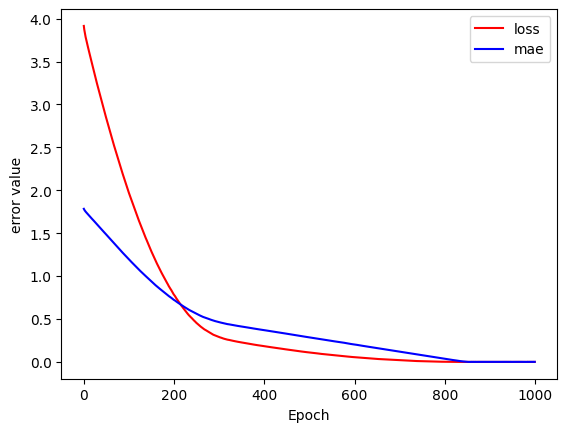

In [21]:
plt.plot(hist.history['loss'], 'r', label='loss')
plt.plot(hist.history['mae'], 'b', label='mae')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('error value')

In [22]:
# 모델 사용
model.predict(np.array([[0],
                        [0.01],
                        [0.02]]))

1/1 [==============================] - 0s 16ms/step


array([[0.32092   ],
       [0.33893207],
       [0.35694414]], dtype=float32)

In [24]:
model.save('model/after_learning.h5')